##Dataset Overview

From what I understood looking at the data, two Excel files were provided MSA1.xlsx and MSA2.xlsx. MSA stands for Metropolitan Statistical Area, which is essentially how the US government defines city regions for data and statistical purposes. So these two files represent apartment property data from two different US city markets, MSA1 being a significantly larger market (Austin, TX area) with around 869 properties, and MSA2 being a smaller market with around 99 properties.

Each file has four sheets, and all four sheets cover the exact same set of properties, they just measure different things about them:

1. Rent — tracks monthly rent figures. This sheet actually has three sections packed side by side: Asking Rent (what the landlord advertises), Effective Rent (what the tenant actually pays after any discounts), and Effective Rent Per Square Foot. The difference between asking and effective rent tells you how much landlords are discounting, a large gap means they're struggling to fill units at their listed price.
2. Occ & Concession — tracks monthly Occupancy % (how full the building is), Concession Value in dollars, and Concession %. Concessions are incentives landlords offer to attract tenants, things like "first month free" or reduced rent for a period. High concessions typically signal weak demand.
3. Asset Class — tracks the quality grade assigned to each property and its submarket over time. This gives context on whether a property is considered Class A (luxury), B (mid-market), or C (older/workforce housing).
4. Property Status — It tracks each property's status every month: S (Stabilized fully leased and operating normally), LU (Lease-Up newly delivered and actively filling units), UC/LU (Under Construction / Lease-Up still being built but already leasing), and R (Rehabilitation undergoing renovation). The transition from LU to S is essentially what lease-up analysis is all about.

###How the Data is Structured

Every sheet follows the same layout:

1. The first 30 columns are property identifiers — things like ProjID, Name, Address, City, State, YearBuilt, Quantity (number of units), AreaPerUnit (average unit size in sqft), Submarket, Latitude, Longitude, and so on. These don't change over time.
2. The remaining 150 columns are monthly time-series data, running from April 2008 through September 2020. Each column is labeled with a month abbreviation like Apr-08, May-08, and so on. So a single row in the Property Status sheet, for example, represents one property and its status every month for 12+ years.

###What can be undertood from the Dataset

This dataset is of apartment properties across two US markets over 12+ years. For each property, we can trace:


*   When it was built and entered the rental market
*   How quickly it filled up with tenants (lease-up speed)
*   What rents it charged and whether those rents held up or declined during lease-up
*   How much it had to discount (concessions) to attract tenants
*   How its quality classification evolved over time

This kind of data is really useful for the real estate business as it helps understand new deal, which assets are underperforming and help compare properties against each other of different markets to uderstand trends

###Known Issues and Limitations in the Data

1. Not all properties are "new deliveries." The majority of properties in both files start with status S — meaning they were already stabilized and operating before April 2008. Only a subset entered the dataset for the first time as LU or UC/LU, meaning they were genuinely new to the market during the observation window.

2. Some ProjIDs appear more than once. Certain projects show up multiple times in the occupancy and rent sheets, once per bedroom type (studio, 1-bedroom, 2-bedroom, etc.). This means you can't just assume one row = one property without checking.

3. Many properties never reach stabilization within the window. Properties delivered close to September 2020 simply don't have enough months left in the dataset to complete lease-up. This creates a problem because we can observe they haven't finished, but we don't know when they will.

4. The dataset has missing values Properties that don't exist yet in a given month have NaN which means every function needs to handle missing data carefully and data cleaning is neccesary.

###Note on Use of Generative AI Tools

To efficiently interpret and understand the structure of these large and complex Excel datasets, generative AI tools including Google Gemini within Google Sheets and Claude were used during this initial phase of understanding. These tools were leveraged to summarize the dataset structure and understand what eah row and column meant. The dataset overview and observations presented above reflect my own understanding derived from this process.







### **Analysis Start**

I will now begin the data processing and analysis. Each step of the workflow will be explained in detail as we proceed through the notebook.

## Step 0 — Install Libraries

Google Colab has most standard libraries pre-installed, but I need a few extra for all the tasks

In [ ]:
!pip install sentence-transformers umap-learn plotly --quiet

## Step 1 — Import the Libraries

I import all libraries at the top so they're easy to find and there's no confusion about what's available later in the notebook. I'm also setting a fixed color palette and chart style here so every plot looks consistent throughout.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

plt.style.use('seaborn-v0_8-whitegrid')  # clean background for all charts
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # fixed palette

## Step 2 — Upload the Dataset

Here i am uploading the two Exel files that were provided for the Task 1 `MSA1.xlsx` and `MSA2.xlsx` so that we can start with the complete analysis and the tasks


In [ ]:
from google.colab import files
print('Select MSA1.xlsx and MSA2.xlsx:')
uploaded = files.upload()
FILE_MSA1 = 'MSA1.xlsx'
FILE_MSA2 = 'MSA2.xlsx'

Select MSA1.xlsx and MSA2.xlsx:


Saving MSA1.xlsx to MSA1 (1).xlsx
Saving MSA2.xlsx to MSA2 (1).xlsx


## Step 3 — Parsing the Excel Files

These Excel files aren't ready to use immediately because they have 'notes' and 'labels' in the first few rows that confuse standard tools.

**The Cleanup Process:**
1. **Skipping the Noise:** We skip the first 3 rows of every sheet to reach the actual data.
2. **Fixed Columns:** Every sheet starts with the same 30 columns describing the property (Name, Address, etc.). We keep these consistent.
3. **Splitting Side-by-Side Data:** The 'Rent' and 'Occ & Concession' sheets actually contain three different tables pasted side-by-side. the code below automatically detects where one table ends and the next begins based on the labels in the second row.
4. **Time-Series Extraction:** We separate the property info from the 150 months of data so we can analyze trends over time without the addresses getting in the way.

In [ ]:
# 1. Define the 30 'Static' columns that identify the property
ID_COLS = [
    'MarketCode', 'MarketName', 'StateCode', 'StateName', 'CountyCode',
    'CountyName', 'TractCode', 'BlockGroupCode', 'Latitude', 'Longitude',
    'ETAKInd', 'True Owner', 'ManagementCompany', 'ProjID', 'Submarket',
    'Name', 'Address', 'City', 'State', 'Zip', 'Phone', 'YearBuilt',
    'Rehab1', 'Rehab2', 'Rehab3', 'Quantity', 'AreaPerUnit',
    'Level', 'Neighborhood', 'Status'
]
N_ID = len(ID_COLS)

def parse_sheet(filepath, sheet_name):
    """Reads a messy sheet and chops it into clean tables."""
    # Load the whole sheet without headers first to see the 'messy' top rows
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # The real headers are in Row 3, Section labels are in Row 2
    col_names    = list(raw.iloc[2, :])
    section_row  = raw.iloc[1, :]

    # Identify where 'Asking Rent', 'Effective Rent', etc., begin
    section_starts = [(i, v) for i, v in enumerate(section_row) if str(v) != 'nan']

    # Actual property data starts from Row 4 onwards
    data = raw.iloc[3:].copy()
    data.columns = col_names
    data = data.reset_index(drop=True)

    # If it's a simple sheet (like Property Status), just return it
    if sheet_name == 'Property Status' or not section_starts:
        df = data.copy()
        df.columns = ID_COLS + list(col_names[N_ID:])
        return {'data': df}

    # For complex sheets, split the side-by-side sections into separate DataFrames
    results = {}
    for k, (start_col, section_name) in enumerate(section_starts):
        end_col   = section_starts[k+1][0] if k+1 < len(section_starts) else len(col_names)

        # Take the ID info (first 30 cols) and glue it to the specific data section
        id_part   = data.iloc[:, :N_ID].copy()
        id_part.columns = ID_COLS
        time_part = data.iloc[:, start_col:end_col].copy()
        time_part.columns = col_names[start_col:end_col]

        results[str(section_name).strip()] = pd.concat([id_part, time_part], axis=1)

    return results

def load_msa(filepath):
    """High-level function to organize all sheets into one easy-to-access dictionary."""
    rent  = parse_sheet(filepath, 'Rent')
    occ   = parse_sheet(filepath, 'Occ & Concession')
    ac    = parse_sheet(filepath, 'Asset Class')

    sheets = {
        'status':        parse_sheet(filepath, 'Property Status')['data'],
        'asking_rent':   rent[list(rent.keys())[0]],
        'eff_rent':      rent[list(rent.keys())[1]],
        'eff_rent_sqft': rent[list(rent.keys())[2]],
        'occupancy':     occ[list(occ.keys())[0]],
        'conc_val':      occ[list(occ.keys())[1]],
        'conc_pct':      occ[list(occ.keys())[2]],
        'asset_class':   ac[list(ac.keys())[0]]
    }

    market = sheets['status']['MarketName'].iloc[0]
    print(f"  {filepath} processed: {len(sheets['status'])} properties found in {market}")
    return sheets

print("Cleaning and loading data...")
msa1 = load_msa(FILE_MSA1)
msa2 = load_msa(FILE_MSA2)
print("Done!")

Cleaning and loading data...
  MSA1.xlsx processed: 869 properties found in Austin-Round Rock, TX
  MSA2.xlsx processed: 99 properties found in Akron, OH
Done!


## Step 4 — Sanity Check

Before diving into complex calculations, I perform a 'Sanity Check' to ensure the parser worked correctly. This step verifies that the data structure is clean and the values are what we expect.

**What we are looking for:**
*   **Date Range:** Confirming we have the full 150 months (Apr-08 to Sep-20).
*   **Status Codes:** Checking that statuses are valid codes like `S` (Stabilized) or `LU` (Lease-up) rather than error values.
*   **Data Alignment:** Previewing a slice of the data to ensure the Property Names and IDs match up with their monthly status values.

In [ ]:
# 1. Identify all the month columns (everything after the 30 ID columns)
# We use the helper function defined in Step 3
def get_month_cols(df):
    return [c for c in df.columns if c not in ID_COLS]

months = get_month_cols(msa1['status'])

# 2. Print high-level stats to verify the timeline and data quality
print(f'Timeline: {months[0]} through {months[-1]} ({len(months)} months total)')

# Look at the first month available to see what property statuses look like
unique_statuses = msa1['status'][months[0]].dropna().unique()
print(f'Status types found in data: {unique_statuses}')

# 3. Display a preview of the first 6 properties
# We show the key identifiers + the first 5 months of status data
preview_cols = ['ProjID', 'Name', 'MarketName', 'YearBuilt', 'Quantity'] + months[:5]
display(msa1['status'][preview_cols].head(6))

Timeline: Apr-08 through Sep-20 (150 months total)
Status types found in data: ['S' 'LU' 'R' 'UC/LU']


,ProjID,Name,MarketName,YearBuilt,Quantity,Apr-08,May-08,Jun-08,Jul-08,Aug-08
0,10031809,108 Place,"Austin-Round Rock, TX",1973,30,NaN,NaN,NaN,NaN,NaN
1,14466,10X Living at Grandview,"Austin-Round Rock, TX",2005,458,S,S,S,S,S
2,89519,1825 Cottages,"Austin-Round Rock, TX",1985,104,S,S,S,S,S
3,43056,21 Pearl,"Austin-Round Rock, TX",2013,135,NaN,NaN,NaN,NaN,NaN
4,10255043,22 North Apartments,"Austin-Round Rock, TX",2018,240,NaN,NaN,NaN,NaN,NaN
5,10029492,24 Flats,"Austin-Round Rock, TX",1974,24,S,S,S,S,S


---
## Task 1.1 — Find Delivered Properties Since April 2008 in the Two Markets

**Definition from the task:** A property is *delivered* if its **first recorded monthly status** is `LU` or `UC/LU`.

Properties that start with `S` (Stabilized) were already occupied before April 2008 — they're not new deliveries in this window, so I exclude them.

The function below loops through each property, finds the **first non-null status entry**, and checks if it's `LU` or `UC/LU`. If yes, that property and that month get stored.

In [ ]:
def find_delivered_properties(status_dataframe):
    """
    Filters for properties that were newly built/delivered during the dataset timeline.
    """
    month_columns = get_month_cols(status_dataframe)
    delivered_properties_list = []

    for _, property_row in status_dataframe.iterrows():
        # Extract only the monthly status sequence for this specific property
        monthly_history = property_row[month_columns]

        # Find the very first month where data exists (ignores the NaNs before it was built)
        first_active_month = monthly_history.first_valid_index()

        if first_active_month is not None:
            # Check the status code in that first active month
            first_status_value = str(monthly_history[first_active_month]).strip()

            # If it started as Lease-Up or Under Construction, it's a new delivery
            if first_status_value in ('LU', 'UC/LU'):
                property_details = property_row.to_dict()
                property_details['delivery_month'] = first_active_month
                property_details['first_status_seen'] = first_status_value
                delivered_properties_list.append(property_details)

    return pd.DataFrame(delivered_properties_list)

# Run the filter for both markets
austin_deliveries = find_delivered_properties(msa1['status'])
akron_deliveries = find_delivered_properties(msa2['status'])

print('=== Delivery Analysis Results ===')
print(f"Austin (MSA1): Found {len(austin_deliveries)} new deliveries out of {len(msa1['status'])} total properties.")
print(f"Akron (MSA2): Found {len(akron_deliveries)} new deliveries out of {len(msa2['status'])} total properties.")

=== Delivery Analysis Results ===
Austin (MSA1): Found 293 new deliveries out of 869 total properties.
Akron (MSA2): Found 5 new deliveries out of 99 total properties.




I am creating a visulization to understand and compare the scale of the two markets and identify specific years where new supply spiked.

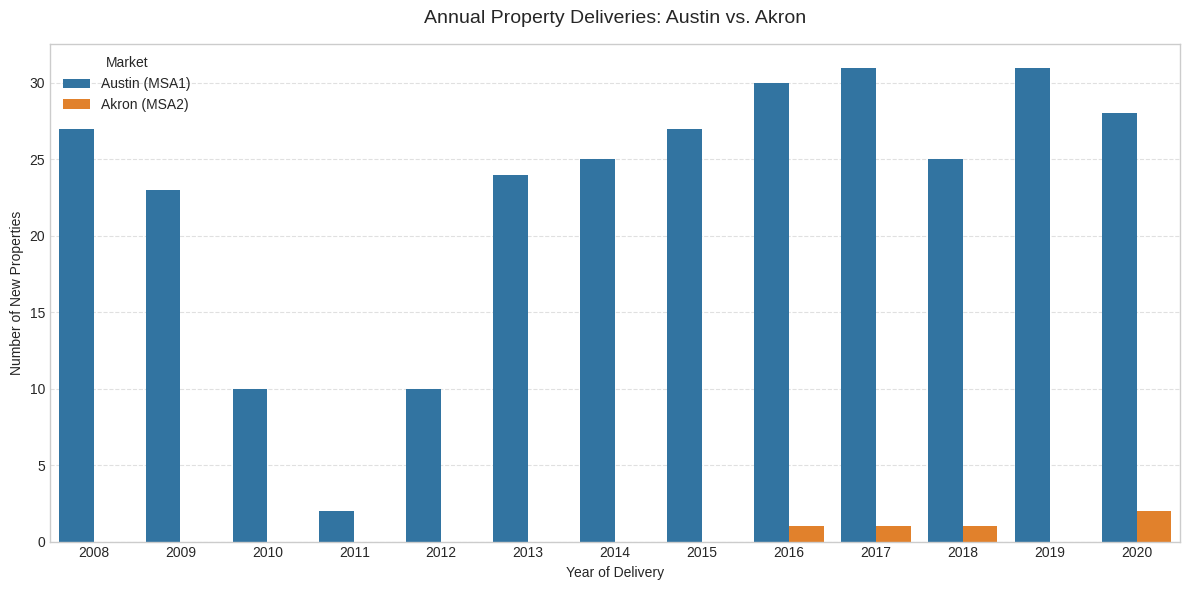

In [ ]:
# 1. Helper function to extract the year from the 'Month-YY' format strings
def extract_year_from_string(month_string):
    return "20" + month_string.split('-')[1]

# 2. Add a 'Year' column to our delivery DataFrames
austin_deliveries['Year'] = austin_deliveries['delivery_month'].apply(extract_year_from_string)
akron_deliveries['Year'] = akron_deliveries['delivery_month'].apply(extract_year_from_string)

# 3. Create a summary for plotting
austin_yearly_summary = austin_deliveries.groupby('Year').size().reset_index(name='Deliveries')
austin_yearly_summary['Market'] = 'Austin (MSA1)'

akron_yearly_summary = akron_deliveries.groupby('Year').size().reset_index(name='Deliveries')
akron_yearly_summary['Market'] = 'Akron (MSA2)'

combined_delivery_plot_data = pd.concat([austin_yearly_summary, akron_yearly_summary])

# 4. Plotting using Seaborn for a cleaner look
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_delivery_plot_data, x='Year', y='Deliveries', hue='Market', palette=COLORS[:2])

plt.title('Annual Property Deliveries: Austin vs. Akron', fontsize=14, pad=15)
plt.ylabel('Number of New Properties')
plt.xlabel('Year of Delivery')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Market')
plt.tight_layout()
plt.show()

## Task 1.2 — Average Lease-Up Time

**Definition:** Lease-up time = months from the delivery month until the **first month occupancy reaches ≥ 90%**.

I cross-reference each delivered property's `delivery_month` with its occupancy row. Starting from delivery, I scan forward month by month until I find a value at or above the 90% threshold.

**Important caveat:** Properties delivered close to September 2020 (the dataset's end) may not have reached 90% yet. I exclude these from the average — including them would artificially inflate lease-up times. This means the averages below are slightly optimistic (biased toward faster leasers).

In [ ]:
def calculate_leaseup_times(delivered_properties, occupancy_data, occupancy_threshold=0.90):
    """
    Calculates the time (in months) from delivery to a target occupancy threshold.
    """
    month_list = get_month_cols(occupancy_data)
    month_to_index_map = {month: index for index, month in enumerate(month_list)}
    occupancy_lookup_table = occupancy_data.set_index('ProjID')

    leaseup_results = []
    for _, property_info in delivered_properties.iterrows():
        project_id = property_info['ProjID']
        delivery_month = property_info['delivery_month']

        if project_id not in occupancy_lookup_table.index:
            continue

        property_occupancy_row = occupancy_lookup_table.loc[project_id]
        if isinstance(property_occupancy_row, pd.DataFrame):
            property_occupancy_row = property_occupancy_row.iloc[0]

        start_index = month_to_index_map.get(delivery_month)
        if start_index is None:
            continue

        # Scan forward from the delivery month
        month_threshold_reached = None
        for month in month_list[start_index:]:
            occupancy_value = property_occupancy_row.get(month)
            if pd.notna(occupancy_value):
                try:
                    if float(occupancy_value) >= occupancy_threshold:
                        month_threshold_reached = month
                        break
                except (ValueError, TypeError):
                    pass

        # Calculate elapsed months
        months_to_stabilize = (month_to_index_map[month_threshold_reached] - start_index) if month_threshold_reached else None

        leaseup_results.append({
            'ProjID': project_id,
            'Name': property_info.get('Name', ''),
            'MarketName': property_info.get('MarketName', ''),
            'delivery_month': delivery_month,
            'hit_90pct_month': month_threshold_reached,
            'leaseup_months': months_to_stabilize
        })

    return pd.DataFrame(leaseup_results)

# Calculate for both markets
austin_leaseup_data = calculate_leaseup_times(austin_deliveries, msa1['occupancy'])
akron_leaseup_data = calculate_leaseup_times(akron_deliveries, msa2['occupancy'])

# Filter for only those that completed lease-up for a clean average
austin_completed_leaseup = austin_leaseup_data.dropna(subset=['leaseup_months'])
akron_completed_leaseup = akron_leaseup_data.dropna(subset=['leaseup_months'])

print('Lease-Up Performance Summary')
for market_label, completed_data, total_data in [
    ('Austin (MSA1)', austin_completed_leaseup, austin_leaseup_data),
    ('Akron (MSA2)', akron_completed_leaseup, akron_leaseup_data)
]:
    print(f'\n{market_label}:')
    print(f'  Total New Deliveries   : {len(total_data)}')
    print(f'  Reached 90% Occupancy  : {len(completed_data)}')
    print(f'  Avg. Lease-Up Speed    : {completed_data["leaseup_months"].mean():.1f} months')
    print(f'  Median Lease-Up Speed : {completed_data["leaseup_months"].median():.1f} months')

Lease-Up Performance Summary

Austin (MSA1):
  Total New Deliveries   : 293
  Reached 90% Occupancy  : 247
  Avg. Lease-Up Speed    : 12.9 months
  Median Lease-Up Speed : 12.0 months

Akron (MSA2):
  Total New Deliveries   : 5
  Reached 90% Occupancy  : 2
  Avg. Lease-Up Speed    : 8.0 months
  Median Lease-Up Speed : 8.0 months


Plotting the Distribution plots for lease up time to understand how quickly or slowly different properties reach stabilization, helping us identify the 'typical' timeframe versus outliers in each market.

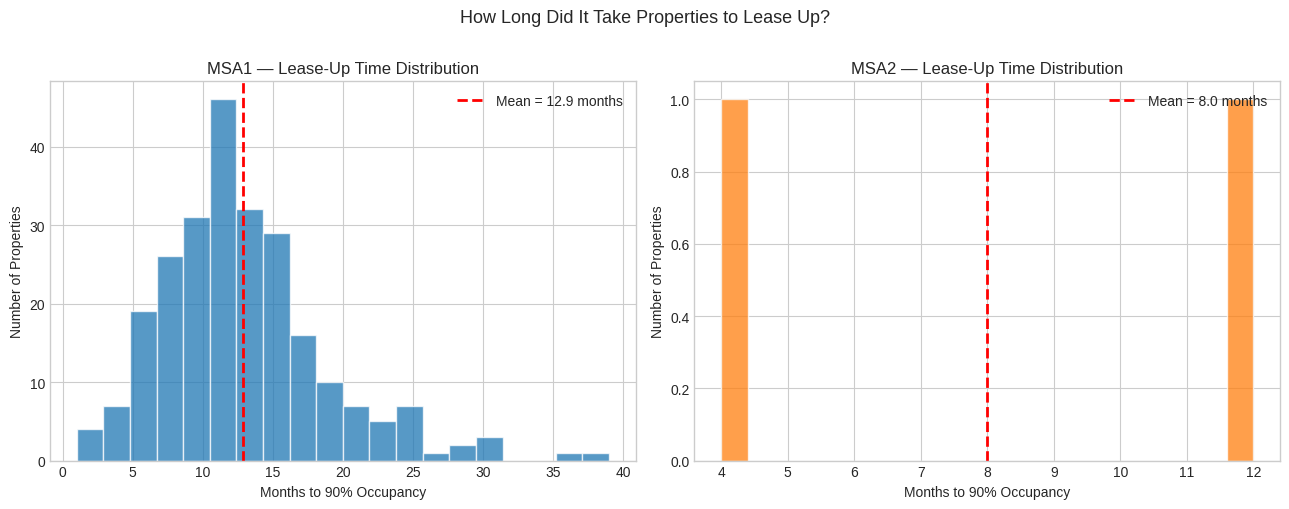

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

markets_to_plot = [
    (austin_completed_leaseup, 'MSA1', COLORS[0]),
    (akron_completed_leaseup, 'MSA2', COLORS[1])
]

for axis, (data_subset, title_label, plot_color) in zip(axes, markets_to_plot):
    average_months = data_subset['leaseup_months'].mean()
    axis.hist(data_subset['leaseup_months'], bins=20, color=plot_color, alpha=0.75, edgecolor='white')
    axis.axvline(average_months, color='red', linestyle='--', linewidth=2, label=f'Mean = {average_months:.1f} months')
    axis.set_xlabel('Months to 90% Occupancy')
    axis.set_ylabel('Number of Properties')
    axis.set_title(f'{title_label} — Lease-Up Time Distribution')
    axis.legend()

plt.suptitle('How Long Did It Take Properties to Lease Up?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The lease-up distribution for MSA1 shows that most properties stabilize within approximately 8 to 16 months, with a mean of 12.9 months. The distribution is slightly right-skewed, indicating that while most properties lease up within a year, a small number take significantly longer, potentially due to weaker demand or suboptimal market conditions.

In contrast, MSA2 has very few completed observations within the dataset, making it difficult to draw statistically reliable conclusions. This limitation is likely due to right-censoring, where recently delivered properties have not yet reached stabilization.

## Task 1.3 — Negative Effective Rent Growth During Lease-Up

From what I understand, **Negative effective** rent growth during lease-up means that, despite filling new units, property owners are collecting less actual revenue per unit over time compared to previous periods, usually due to heavy incentives needed to attract tenants in a soft market. In the real estate industry, 'Effective Rent' is the 'Asking Rent' minus any 'Concessions' (like 1 month free or discounted parking).

**Why it matters:**
For an investment firm, negative growth during lease-up is a red flag. It means the property is not meeting its financial projections and might be less profitable than originally planned. In this task, we measure the change from the **delivery month** to the **month the property hit 90% occupancy** to see which properties had to 'buy' their occupancy by lowering prices.

In [ ]:
def calculate_rent_growth_during_leaseup(leaseup_dataframe, effective_rent_data):
    """Computes effective rent growth from delivery to lease-up completion."""
    rent_lookup_table = effective_rent_data.set_index('ProjID')
    growth_results = []

    valid_completed_cases = leaseup_dataframe.dropna(subset=['leaseup_months', 'hit_90pct_month'])

    for _, property_row in valid_completed_cases.iterrows():
        project_id = property_row['ProjID']
        start_month = property_row['delivery_month']
        end_month = property_row['hit_90pct_month']

        if project_id not in rent_lookup_table.index:
            continue

        rent_history_row = rent_lookup_table.loc[project_id]
        if isinstance(rent_history_row, pd.DataFrame):
            rent_history_row = rent_history_row.iloc[0]

        try:
            starting_rent = float(rent_history_row[start_month])
            ending_rent = float(rent_history_row[end_month])
            percentage_growth = ((ending_rent - starting_rent) / starting_rent * 100) if starting_rent > 0 else None
        except (KeyError, TypeError, ValueError):
            starting_rent = ending_rent = percentage_growth = None

        growth_results.append({
            'ProjID': project_id,
            'Name': property_row['Name'],
            'MarketName': property_row['MarketName'],
            'delivery_month': start_month,
            'leaseup_months': property_row['leaseup_months'],
            'rent_at_delivery': starting_rent,
            'rent_at_90pct': ending_rent,
            'rent_growth_pct': percentage_growth,
        })

    return pd.DataFrame(growth_results)

# Run calculation for both markets
austin_rent_growth = calculate_rent_growth_during_leaseup(austin_leaseup_data, msa1['eff_rent'])
akron_rent_growth = calculate_rent_growth_during_leaseup(akron_leaseup_data, msa2['eff_rent'])

# Combine and filter for valid data
all_market_rent_growth = pd.concat([austin_rent_growth, akron_rent_growth], ignore_index=True)
valid_rent_growth_records = all_market_rent_growth.dropna(subset=['rent_growth_pct'])

# Identify negative performers
negative_growth_properties = valid_rent_growth_records[valid_rent_growth_records['rent_growth_pct'] < 0].sort_values('rent_growth_pct')

print(f'Properties with rent growth data : {len(valid_rent_growth_records)}')
print(f'Negative rent growth             : {len(negative_growth_properties)} ({len(negative_growth_properties)/len(valid_rent_growth_records)*100:.1f}%)')
print(f'Average growth (all)             : {valid_rent_growth_records["rent_growth_pct"].mean():.1f}%')

print('\nWorst performers (most negative growth):')
display(negative_growth_properties[['Name', 'MarketName', 'delivery_month', 'leaseup_months',
                                     'rent_at_delivery', 'rent_at_90pct', 'rent_growth_pct']].head(10))

Properties with rent growth data : 249
Negative rent growth             : 104 (41.8%)
Average growth (all)             : 1.0%

Worst performers (most negative growth):


,Name,MarketName,delivery_month,leaseup_months,rent_at_delivery,rent_at_90pct,rent_growth_pct
59,Colonial Grand at Ashton Oaks,"Austin-Round Rock, TX",Oct-08,14.0,992.0,653.0,-34.173387
229,Villas at Tech Ridge,"Austin-Round Rock, TX",Mar-09,15.0,1141.0,841.0,-26.292726
1,3500 Westlake,"Austin-Round Rock, TX",Apr-08,12.0,1695.0,1276.0,-24.719764
14,AMLI on 2ND,"Austin-Round Rock, TX",Apr-08,5.0,2479.0,1897.0,-23.477209
127,Marquis Lakeline Station,"Austin-Round Rock, TX",May-08,11.0,981.0,770.0,-21.508665
145,Park at Crystal Falls I,"Austin-Round Rock, TX",Sep-16,19.0,1344.0,1079.0,-19.717262
45,Broadstone Grand Avenue,"Austin-Round Rock, TX",Sep-09,12.0,997.0,805.0,-19.257773
162,RiverView,"Austin-Round Rock, TX",Jul-13,16.0,2448.0,1978.0,-19.199346
172,Springs at Lakeline,"Austin-Round Rock, TX",Jul-17,19.0,1352.0,1093.0,-19.156805
190,The Bridge at Centeridge,"Austin-Round Rock, TX",Jun-08,11.0,865.0,708.0,-18.150289


### **Visualizing Rent Growth Performance**

 we use two complementary charts to visualize the financial health of properties during their lease-up phase:

1.  **The Distribution (Histogram):** This shows us the 'frequency' of rent changes. We want to see how many properties managed to grow their rents versus how many were forced into the 'negative' zone (left of the red dashed line).
2.  **The Correlation (Scatter Plot):** Here, we compare **Lease-Up Speed** against **Rent Growth**. This helps us understabd a question which is  *Do properties that take longer to fill up also suffer the worst rent declines?* Properties in the bottom-right quadrant are the highest risk, as they are both slow to stabilize and losing effective rental value.

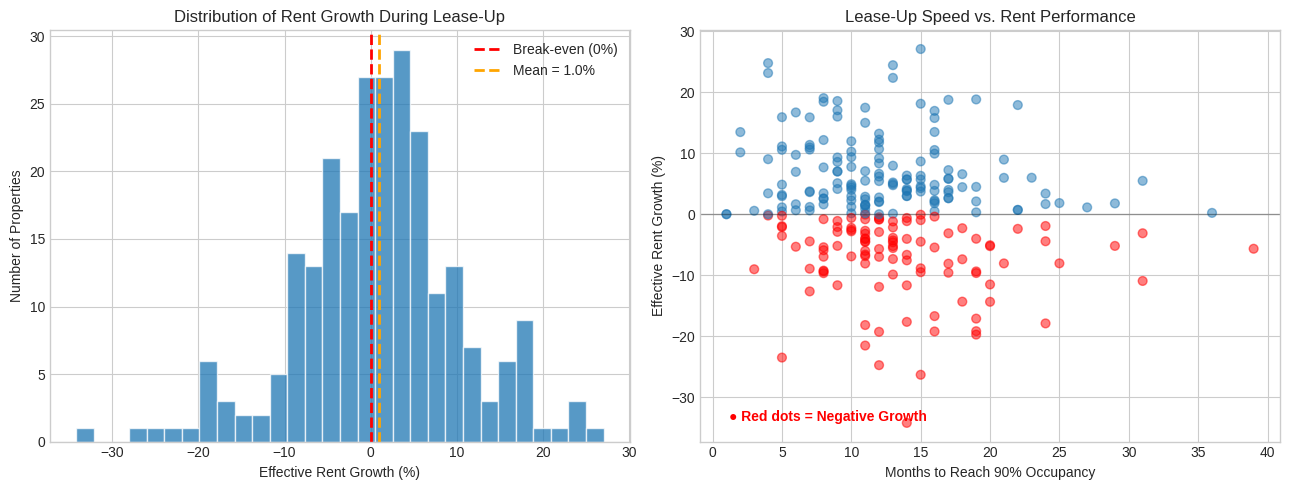

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left Chart: Distribution of Rent Growth
# This shows how common it is for properties to hit or miss their rent targets
axes[0].hist(valid_rent_growth_records['rent_growth_pct'], bins=30, color=COLORS[0], alpha=0.75, edgecolor='white')

# Add a line at 0% to clearly separate gainers from losers
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even (0%)')

# Add a line for the market average
market_average_growth = valid_rent_growth_records['rent_growth_pct'].mean()
axes[0].axvline(market_average_growth, color='orange', linestyle='--',
                linewidth=2, label=f'Mean = {market_average_growth:.1f}%')

axes[0].set_xlabel('Effective Rent Growth (%)')
axes[0].set_ylabel('Number of Properties')
axes[0].set_title('Distribution of Rent Growth During Lease-Up')
axes[0].legend()

# Right Chart: Relationship Analysis
# We color the dots red if the growth was negative to make outliers stand out
point_colors = ['red' if growth < 0 else COLORS[0] for growth in valid_rent_growth_records['rent_growth_pct']]

axes[1].scatter(valid_rent_growth_records['leaseup_months'],
                valid_rent_growth_records['rent_growth_pct'],
                c=point_colors, alpha=0.5, s=40)

# Add a horizontal baseline at 0%
axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

axes[1].set_xlabel('Months to Reach 90% Occupancy')
axes[1].set_ylabel('Effective Rent Growth (%)')
axes[1].set_title('Lease-Up Speed vs. Rent Performance')

# Add a small note to explain the coloring
axes[1].text(0.05, 0.05, '● Red dots = Negative Growth', transform=axes[1].transAxes,
             color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Task 1.4 — Feature Engineering

The goal here is to create new meaningful features from the existing data that could help a model predict how long a property will take to lease up. The way I thought about this was instead of just using raw monthly columns directly, can I summarize them into single numbers that actually mean something about the property's leasing behavior?

The best way I can describe feature engineering here is similar to how BMI works. You already have height and weight as separate raw measurements, but combining them into one ratio gives you something far more meaningful than either number alone. Same idea here I'm taking raw monthly occupancy values, rent figures, and concession percentages and computing derived numbers that capture real signals about lease-up speed.

**Feature 1: early_occ_growth** — Early Occupancy Momentum
In the first 3 months after a property is delivered, how fast is it filling up?

```
early_occ_growth = (occupancy_month3 - occupancy_month1) / 2
```

A property going from 20% to 50% occupancy in its first 3 months has a slope of +15 percentage points per month. A property going from 20% to 24% has a slope of +2. The first one is clearly gaining tenants much faster. This is observable very early just 3 months after delivery and acts as a leading indicator of how the full lease-up will play out. If a building gains momentum quickly at the start, it almost always finishes faster.

**Feature 2: price_vs_market_pct** — Pricing Relative to the Submarket at Delivery. Is this property charging more or less than its neighbors at the time it opens?

```
price_vs_market_pct = (property_asking_rent_at_delivery - submarket_median_rent_that_month) / submarket_median_rent_that_month × 100
```

This feature is computed by taking the property's asking rent at its delivery month and comparing it against the median asking rent of all other properties in the same submarket during that same month. The result is expressed as a percentage how far above or below the submarket median this property is priced. A positive value means the property is priced above its submarket peers at the time of delivery, while a negative value means it is priced below. This gives the model a sense of where the property sits competitively in its local market from the moment it opens, which is a factor that directly influences how quickly tenants choose it over alternatives.


**Feature 3: delivery_season** — What Season Did the Property Open?
Did this building open during peak renting season or the dead of winter?

```
Jan / Feb / Mar → Q1
Apr / May / Jun → Q2  ← peak leasing season
Jul / Aug / Sep → Q3  ← strong leasing season
Oct / Nov / Dec → Q4  ← slowest season
```

This feature maps the delivery month to the quarter it falls in using a simple lookup. Before assigning the categories I did some research into US residential leasing patterns and found that demand consistently peaks between April and September, covering Q2 and Q3. This is when most leases expire, job relocations happen, and students search for housing ahead of the academic year. Q4 and Q1 are noticeably slower — fewer people are actively looking to move. Based on this, the quarter of delivery tells the model what demand environment the property entered when it first opened, which directly influences how quickly it could find tenants.

**Feature 4: building_age_group** — How New Is the Building?

```
YearBuilt >= 2010  → "New (2010+)"
YearBuilt 2000–09  → "Recent (2000-09)"
YearBuilt 1990–99  → "Mid (1990-99)"
YearBuilt < 1990   → "Old (<1990)"
```
This feature takes the existing YearBuilt column and buckets it into four categories. Having lived in an older apartment and visited newer ones, the difference is immediately obvious — newer buildings have better layouts, modern kitchens, in-unit laundry, and amenities like gyms or rooftop spaces. Older buildings tend to have smaller rooms, dated fittings, and fewer shared facilities. From a tenant's perspective, if two buildings are priced similarly, the newer one wins almost every time. This means newer properties generally attract tenants faster without having to compete as hard on price. I bucketed the raw year rather than using it directly because 1985 and 1986 are not meaningfully different to a tenant, what matters is the general era the building belongs to.

**Feature 5: avg_concession_pct** — Average Concession Level During Lease-Up

```
avg_concession_pct = mean(monthly concession % values from delivery month → 90% occupancy month)
```

Concessions are the discounts landlords offer to attract tenants things like one month of free rent or reduced rates for the first few months of a lease. A property averaging 2% concessions throughout lease-up is barely discounting, meaning tenants are coming at close to full price demand is healthy. A property averaging 10% is essentially giving away over a month of free rent per year, which signals the market is not naturally absorbing this building and the landlord is having to compensate. High average concessions throughout lease-up correlate strongly with longer lease up times because both reflect the same underlying reality demand is weaker than expected.



In [ ]:
def build_features(leaseup_df, occupancy_df, asking_rent_df, concession_df, status_df):
    """
    Builds 5 predictive features for each property that completed lease-up.
    """
    month_list = get_month_cols(occupancy_df)
    month_to_index = {month: i for i, month in enumerate(month_list)}

    occupancy_lookup = occupancy_df.set_index('ProjID')
    asking_lookup = asking_rent_df.set_index('ProjID')
    concession_lookup = concession_df.set_index('ProjID')
    status_lookup = status_df.set_index('ProjID')

    submarket_median_cache = {}

    def get_time_series_values(lookup_table, project_id, start_idx, end_idx):
        if project_id not in lookup_table.index:
            return []
        row_data = lookup_table.loc[project_id]
        if isinstance(row_data, pd.DataFrame):
            row_data = row_data.iloc[0]

        values = []
        for m in month_list[start_idx:end_idx+1]:
            val = row_data.get(m)
            if pd.notna(val):
                try:
                    values.append(float(val))
                except:
                    pass
        return values

    feature_results = []
    for _, property_row in leaseup_df.dropna(subset=['leaseup_months']).iterrows():
        project_id = property_row['ProjID']
        delivery_month = property_row['delivery_month']
        leaseup_duration = int(property_row['leaseup_months'])

        delivery_idx = month_to_index.get(delivery_month)
        if delivery_idx is None:
            continue

        stabilization_idx = min(delivery_idx + leaseup_duration, len(month_list) - 1)

        occ_values = get_time_series_values(occupancy_lookup, project_id, delivery_idx, stabilization_idx)
        conc_values = get_time_series_values(concession_lookup, project_id, delivery_idx, stabilization_idx)
        ask_values = get_time_series_values(asking_lookup, project_id, delivery_idx, stabilization_idx)
        early_occ = get_time_series_values(occupancy_lookup, project_id, delivery_idx, min(delivery_idx+2, stabilization_idx))

        # 1. early_occ_growth
        early_occ_growth = (early_occ[-1] - early_occ[0]) / max(len(early_occ) - 1, 1) if len(early_occ) >= 2 else np.nan

        # 2. avg_concession_pct
        avg_concession_pct = np.nanmean(conc_values) if conc_values else np.nan

        # 3. building_age_group
        year_built = status_lookup.loc[project_id, 'YearBuilt'] if project_id in status_lookup.index else np.nan
        if isinstance(year_built, pd.Series):
            year_built = year_built.iloc[0]

        try:
            yb_int = int(year_built)
            building_age_group = (
                'New (2010+)' if yb_int >= 2010 else
                'Recent (2000-09)' if yb_int >= 2000 else
                'Mid (1990-99)' if yb_int >= 1990 else
                'Old (<1990)'
            )
        except:
            building_age_group = 'Unknown'

        # 4. delivery_season
        try:
            month_num = pd.to_datetime(delivery_month, format='%b-%y').month
            delivery_season = {
                1:'Q1', 2:'Q1', 3:'Q1',
                4:'Q2', 5:'Q2', 6:'Q2',
                7:'Q3', 8:'Q3', 9:'Q3',
                10:'Q4', 11:'Q4', 12:'Q4'
            }[month_num]
        except:
            delivery_season = 'Unknown'

        # 5. price_vs_market_pct
        property_submarket = status_lookup.loc[project_id, 'Submarket'] if project_id in status_lookup.index else ""
        if isinstance(property_submarket, pd.Series):
            property_submarket = property_submarket.iloc[0]

        cache_key = (property_submarket, delivery_month)
        if cache_key not in submarket_median_cache and property_submarket:
            submarket_peers = status_lookup[status_lookup['Submarket'] == property_submarket].index
            peer_rents = []
            for peer_id in submarket_peers:
                if peer_id in asking_lookup.index:
                    p_row = asking_lookup.loc[peer_id]
                    if isinstance(p_row, pd.DataFrame):
                        p_row = p_row.iloc[0]
                    p_val = p_row.get(delivery_month)
                    if pd.notna(p_val):
                        try:
                            peer_rents.append(float(p_val))
                        except:
                            pass
            submarket_median_cache[cache_key] = np.median(peer_rents) if peer_rents else np.nan

        median_val = submarket_median_cache.get(cache_key, np.nan)
        this_ask = ask_values[0] if ask_values else np.nan
        price_vs_market_pct = (
            (this_ask - median_val) / median_val * 100
            if (pd.notna(median_val) and median_val > 0 and pd.notna(this_ask))
            else np.nan
        )

        feature_results.append({
            'ProjID': project_id,
            'Name': property_row['Name'],
            'MarketName': property_row['MarketName'],
            'leaseup_months': leaseup_duration,
            'early_occ_growth': early_occ_growth,
            'avg_concession_pct': avg_concession_pct,
            'building_age_group': building_age_group,
            'delivery_season': delivery_season,
            'price_vs_market_pct': price_vs_market_pct
        })

    return pd.DataFrame(feature_results)


print('Building Features')
austin_features = build_features(austin_completed_leaseup, msa1['occupancy'], msa1['asking_rent'], msa1['conc_pct'], msa1['status'])
akron_features = build_features(akron_completed_leaseup, msa2['occupancy'], msa2['asking_rent'], msa2['conc_pct'], msa2['status'])

final_feature_set = pd.concat([austin_features, akron_features], ignore_index=True)

display(final_feature_set[['Name', 'leaseup_months', 'early_occ_growth', 'avg_concession_pct', 'building_age_group', 'delivery_season', 'price_vs_market_pct']].head(10))

Building Features


,Name,leaseup_months,early_occ_growth,avg_concession_pct,building_age_group,delivery_season,price_vs_market_pct
0,22 North Apartments,4,0.0895,0.082425,New (2010+),Q2,3.617363
1,3500 Westlake,12,0.0200,0.143535,Recent (2000-09),Q2,65.527344
2,422 At The Lake,15,0.0845,0.089269,New (2010+),Q2,62.379897
3,5th Street Commons,8,0.0765,0.152265,Recent (2000-09),Q4,13.210084
4,7East,13,0.0475,0.062138,New (2010+),Q3,93.639208
5,95 Twenty,13,0.0630,0.031091,New (2010+),Q3,11.223458
6,Agave at South Congress,8,0.0385,0.047549,Recent (2000-09),Q1,24.013158
7,Altair Tech Ridge,7,0.0390,0.056530,New (2010+),Q1,38.669335
8,Altis Lakeline,20,0.0635,0.119152,New (2010+),Q3,16.298812
9,AMLI 300,19,0.0780,0.082414,Recent (2000-09),Q2,37.619699


Creating visualization (Scatter plots) of each numeric feature vs lease-up time, with Pearson correlation shown in the title. Strong predictors show up as tight patterns; the red title means r > 0.2.

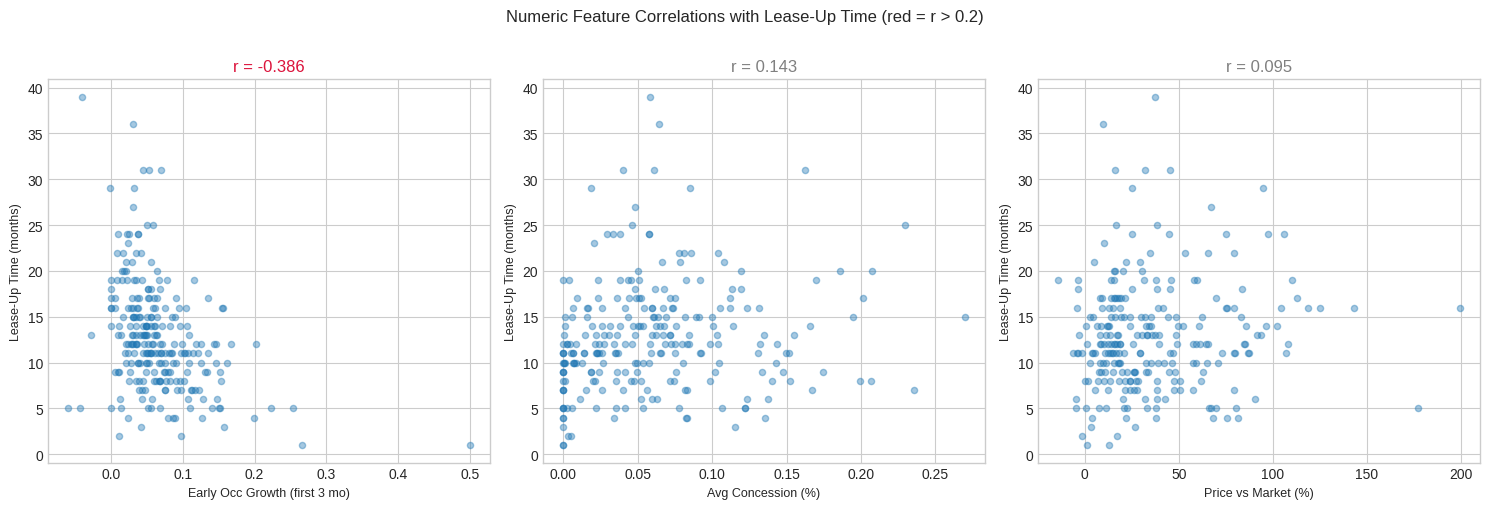

In [ ]:
num_feats = ['early_occ_growth', 'avg_concession_pct', 'price_vs_market_pct']
feat_lbls = ['Early Occ Growth (first 3 mo)', 'Avg Concession (%)', 'Price vs Market (%)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, lbl in zip(axes.flat, num_feats, feat_lbls):
    sub = final_feature_set.dropna(subset=[col, 'leaseup_months'])
    ax.scatter(sub[col], sub['leaseup_months'], alpha=0.4, s=20, color=COLORS[0])
    r = sub[[col, 'leaseup_months']].corr().iloc[0, 1]   # Pearson correlation
    ax.set_xlabel(lbl, fontsize=9)
    ax.set_ylabel('Lease-Up Time (months)', fontsize=9)
    ax.set_title(f'r = {r:.3f}', color='crimson' if abs(r) > 0.2 else 'gray')

plt.suptitle('Numeric Feature Correlations with Lease-Up Time (red = r > 0.2)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('feat_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

###Understanding the Scatterplot

**Early Occupancy Growth (r = -0.386)**
The negative correlation means that properties which fill up faster in the first few months tend to complete lease-up sooner overall. If a building gains tenants quickly at the start, it usually continues that momentum. In the plot, properties with high early growth mostly have shorter lease-up times, while those with slow early growth are spread across much longer durations.

**Average Concession Percentage (r = 0.143)**

The relationship here is weak but directionally correct. Properties offering higher concessions tend to take slightly longer to lease up, but the pattern is not strong. This is likely because concessions alone do not fully capture demand. Some properties offer discounts but still lease quickly due to strong location or market conditions. So this feature is useful, but not reliable on its own.

**Price Relative to Market (r = 0.095)**

This is the weakest relationship among the three. There is no clear pattern between pricing and lease-up time in the current plot. One reason is the presence of extreme outliers, where a few properties are priced far above the market. These stretch the scale and make the main trend harder to see. Overall, pricing seems to work better as a supporting feature rather than a primary driver.

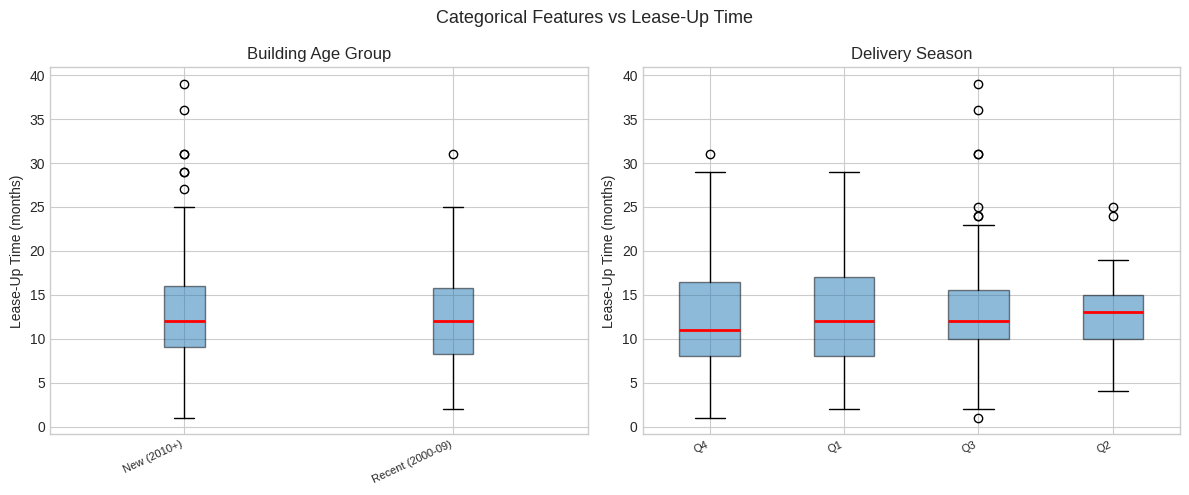

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
                           ['building_age_group', 'delivery_season'],
                           ['Building Age Group', 'Delivery Season']):
    sub   = final_feature_set.dropna(subset=['leaseup_months', col])
    # Sort categories by their median lease-up time for a cleaner visual flow
    order = sub.groupby(col)['leaseup_months'].median().sort_values().index.tolist()
    groups = [sub[sub[col] == cat]['leaseup_months'].values for cat in order]


    ax.boxplot(groups, tick_labels=order, patch_artist=True,
               boxprops=dict(facecolor=COLORS[0], alpha=0.5),
               medianprops=dict(color='red', linewidth=2))

    ax.set_ylabel('Lease-Up Time (months)')
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.suptitle('Categorical Features vs Lease-Up Time', fontsize=13)
plt.tight_layout()
plt.show()

###Understanding the Box Plots

**Building Age Group**

There is no clear difference in lease-up time across building age groups. Both "New (2010+)" and "Recent (2000–09)" properties have very similar median lease-up times, around 12 months, and their distributions overlap heavily. This suggests that, in this dataset, building age does not strongly affect how quickly a property leases up. One possible reason is that even buildings from 2000–09 are still relatively modern and competitive. Also, slower lease-ups appear in all age groups, indicating that other factors play a bigger role than age alone.

**Delivery Season**

This feature shows a more noticeable pattern. Properties delivered in Q2 (spring) tend to lease up slightly faster and more consistently, with a lower median and a tighter spread.
Q4 (winter) shows a higher median and more variation, meaning outcomes are less predictable. Q1 and Q3 fall somewhere in between.

Overall, the differences are not very large, but the direction makes sense. Spring deliveries benefit from higher rental demand, while winter tends to be slower. At the same time, the wide spread in all seasons shows that timing alone does not determine performance, other factors still matter.

## Task 1.5 — Embedding-Based Property Clustering

The task asks to use an embedding model to group similar properties and explain what the clusters reveal.

My approach was to convert each property into a short text "profile card" combining its name, market, vintage, size tier, delivery season, and key numeric features into a single readable sentence. I then feed these into a **sentence transformer** model (`all-MiniLM-L6-v2`), which converts them into 384-dimensional vectors. Similar properties end up with similar vectors.

After that:
- **UMAP** reduces 384 dimensions → 2 dimensions so we can actually plot the clusters
- **K-Means** assigns each property to a cluster

**Why this approach over plain K-Means on numeric features?** Embeddings can capture the joint meaning of all features together including text fields like property name and submarket in a way that tabular clustering can't. A sentence transformer "understands" that 'Far West Austin' and 'Northwest Austin' are related, whereas K-Means treats them as arbitrary strings.

In [ ]:
def make_card(row):
    """Formats a property profile as a sentence for the embedding model to read."""
    return (
        f"Property: {row.get('Name', 'Unknown')}. "
        f"Market: {row.get('MarketName', 'Unknown')}. "
        f"Building age: {row.get('building_age_group', 'Unknown')}. "
        f"Delivered in: {row.get('delivery_season', 'Unknown')}. "
        f"Lease-up time: {row.get('leaseup_months', 'NA')} months. "
        f"Early occupancy growth: {round(row['early_occ_growth'], 3) if pd.notna(row.get('early_occ_growth')) else 'NA'}. "
        f"Avg concession: {round(row['avg_concession_pct'], 3) if pd.notna(row.get('avg_concession_pct')) else 'NA'}. "
        f"Price vs market: {round(row['price_vs_market_pct'], 1) if pd.notna(row.get('price_vs_market_pct')) else 'NA'}%."
    )

final_feature_set['property_card'] = final_feature_set.apply(make_card, axis=1)

print('Example property card:')
print(final_feature_set['property_card'].iloc[0])

Example property card:
Property: 22 North Apartments. Market: Austin-Round Rock, TX. Building age: New (2010+). Delivered in: Q2. Lease-up time: 4 months. Early occupancy growth: 0.09. Avg concession: 0.082. Price vs market: 3.6%.


Now running the embedding model. It downloads ~80MB on first run (just once). Each property card gets converted to a 384-dimensional vector.

In [ ]:
from sentence_transformers import SentenceTransformer
import umap

print('Loading embedding model (downloads ~80MB on first run)...')
embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # free CPU-friendly model, 384-dim output

print(f'Encoding {len(final_feature_set)} properties...')
text_emb = embed_model.encode(
    final_feature_set['property_card'].tolist(),
    batch_size=64,
    show_progress_bar=True
)
print(f'Done. Embedding shape: {text_emb.shape}')  # should be (n_properties, 384)

Loading embedding model (downloads ~80MB on first run)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 249 properties...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Done. Embedding shape: (249, 384)


I combine the text embeddings (80% weight) with key numeric features (20% weight) so both signals influence the clusters. Then UMAP reduces to 2D for plotting, and K-Means assigns cluster labels.

I chose k=5 based on the elbow method (next cell) a judgment call between the curve flattening and keeping the clusters interpretable.

In [ ]:
# Scale the 3 numeric features before combining with embeddings
num_cols   = ['early_occ_growth', 'avg_concession_pct', 'price_vs_market_pct']
num_data   = final_feature_set[num_cols].fillna(0).values
num_scaled = StandardScaler().fit_transform(num_data)

# Combine: 80% text embedding signal, 20% numeric feature signal
combined = np.hstack([text_emb * 0.8, num_scaled * 0.2])

# UMAP: reduce from 384 dimensions down to 2D for visualization
print('Running UMAP (takes ~30 seconds)...')
xy = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(combined)

# K-Means: assign each property to a cluster
N_CLUSTERS = 5
labels = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(combined)

final_feature_set['cluster'] = labels
final_feature_set['umap_x']  = xy[:, 0]
final_feature_set['umap_y']  = xy[:, 1]

print('Cluster sizes:')
print(final_feature_set['cluster'].value_counts().sort_index())

Running UMAP (takes ~30 seconds)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Cluster sizes:
cluster
0     44
1    106
2     51
3     47
4      1
Name: count, dtype: int64


###Elbow Method and Silhouette Score Visualization

The Elbow Method (left chart) shows how the total variation within clusters decreases as the number of clusters increases. As expected, the value drops as k increases, since each cluster becomes smaller and more specific. The goal is to identify the point where adding more clusters no longer provides meaningful improvement. In this case, the curve begins to flatten around k = 4 to k = 5, indicating that beyond this point, additional clusters do not significantly improve the grouping. This suggests that k = 5 is a reasonable choice.

The Silhouette Score (right chart) measures how well-separated the clusters are. Higher values indicate clearer and more distinct groupings. The score is highest at k = 3, meaning that three clusters provide the best separation mathematically. However, using only three clusters would result in groups that are too broad for meaningful interpretation. At k = 5, the score remains reasonably strong before declining more noticeably for higher values of k.

Considering both metrics together, k = 5 provides a good balance. It captures most of the improvement seen in the elbow method while still maintaining acceptable cluster separation. More importantly, it produces clusters that are detailed enough to interpret and draw meaningful insights from

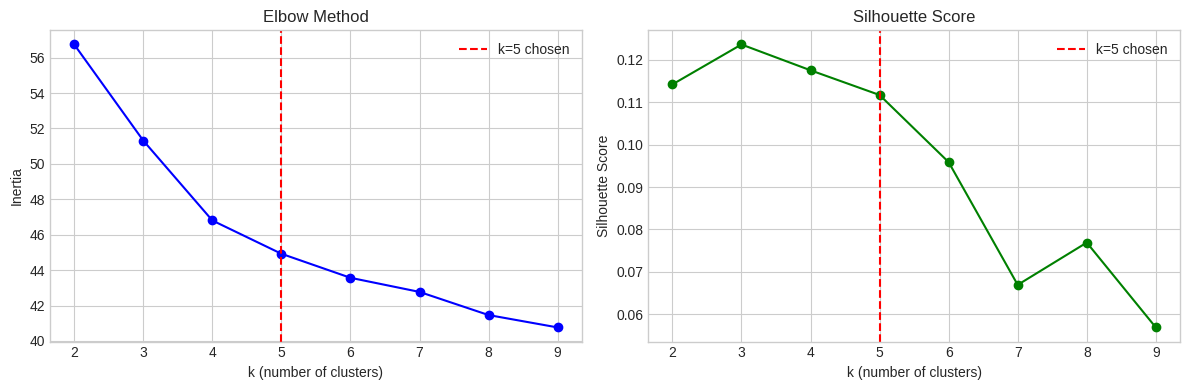

In [ ]:
inertias, silhouettes = [], []

for k in range(2, 10):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbs = km.fit_predict(combined)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(combined, lbs, sample_size=min(500, len(combined))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 10), inertias, 'bo-')
axes[0].axvline(N_CLUSTERS, color='red', linestyle='--', label=f'k={N_CLUSTERS} chosen')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(range(2, 10), silhouettes, 'go-')
axes[1].axvline(N_CLUSTERS, color='red', linestyle='--', label=f'k={N_CLUSTERS} chosen')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

###Umap Scatter Plot Visualization

The clustering results group properties with similar characteristics and lease-up behavior. Each cluster represents a distinct pattern in how properties performed during lease-up.

**Cluster 1 (red)** represents the largest and most central group. These properties are spread across the middle of the chart and show a wide range of lease-up times, as indicated by varying dot sizes. This suggests that they are typical market properties without extreme characteristics. They likely reflect average pricing, average concessions, and standard leasing behavior.

**Cluster 2 (green)** is located in the upper left region and contains noticeably larger dots. This indicates that properties in this group generally took longer to lease up. Their separation from the main cluster suggests that they share common traits, such as weaker early demand or higher reliance on concessions, which may have slowed their lease-up process.

**Cluster 0 (blue)** appears in the lower left region and is relatively tightly grouped. The dots are generally smaller, indicating faster lease-up times. This suggests that these properties benefited from favorable conditions, such as strong demand, competitive pricing, or good timing at delivery.

**Cluster 3 (purple)** is positioned on the right side of the chart and is more spread out. Lease-up times vary within this group, but the cluster is clearly separated from the main segment. This indicates that these properties likely have distinct characteristics, possibly related to pricing differences or unique positioning within their submarkets.

**Cluster 4 (orange)** consists of a single property located in the bottom right corner. This is an outlier, meaning its characteristics are significantly different from all other properties. This property would be worth further investigation to understand what makes it unique.

In [ ]:
fig = px.scatter(
    final_feature_set.dropna(subset=['umap_x', 'umap_y']),
    x='umap_x',
    y='umap_y',
    color=final_feature_set['cluster'].astype(str),
    size='leaseup_months',
    size_max=20,
    hover_data=['Name', 'MarketName', 'building_age_group',
                'delivery_season', 'leaseup_months',
                'early_occ_growth', 'avg_concession_pct', 'price_vs_market_pct'],
    title='Property Clusters (UMAP + K-Means, k=5) — dot size = lease-up months',
    labels={'color': 'Cluster', 'umap_x': 'UMAP Dim 1', 'umap_y': 'UMAP Dim 2'},
    color_discrete_sequence=px.colors.qualitative.Set1,
    width=900, height=570
)
fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color='white')))
fig.show()

###Understanding the Heatmap Visualization

Heatmap below makes the clusters interpretable. Each row is a feature, each column is a cluster. The **color** is normalized (red = high, green = low within that feature). The **number** inside each cell is the actual mean value. This lets me describe what each cluster represents.

What the Clusters Tell Us

The heatmap shows that each cluster represents a distinct type of property with different lease-up behavior. The differences are driven by a combination of early demand, pricing, concessions, and timing.

Cluster 3 — Fast performers
This group has the fastest lease-up time, averaging around 9 months. These properties show the highest early occupancy growth and the lowest concession levels. Most are newer buildings and many were delivered during Q3, which is a strong leasing period. Overall, these properties benefited from strong demand and good timing, allowing them to lease quickly and consistently.

Cluster 4 — Outlier
This cluster contains a single property that leased up extremely quickly in just 1 month. It has very high early occupancy growth and no concessions. Its behavior is very different from all other properties, which is why it appears as its own cluster. This property is worth investigating separately.

Cluster 1 — Typical slower performers
These properties have one of the highest average lease-up times, around 14 months. They are mostly newer buildings, but show low early occupancy growth and moderate concession levels. There are no extreme issues, but also no strong positive signals, which results in slower and less efficient lease-up.

Cluster 2 — High-priced slow performers
This group also has a high average lease-up time, but for a different reason. These properties are priced significantly above their submarket average. While they are mostly new buildings, the higher pricing likely reduced demand. A larger share of Q4 deliveries may have also contributed to slower leasing conditions.

Cluster 0 — Older properties with higher concessions
This cluster stands out because it includes a higher share of older buildings. These properties offer the highest concessions among all clusters, suggesting they needed to discount more to remain competitive. Despite this, they achieved a moderate lease-up time of around 13 months, indicating that concessions helped offset weaker positioning.

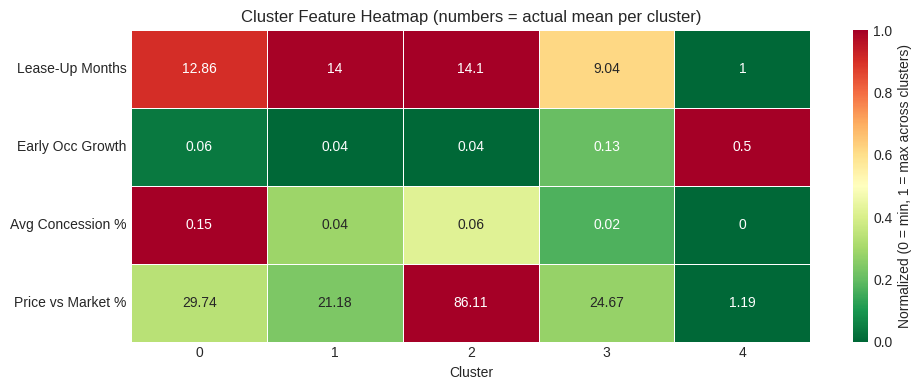

Building age group distribution by cluster:


building_age_group,New (2010+),Recent (2000-09)
cluster,,
0,0.36,0.64
1,0.89,0.11
2,0.82,0.18
3,0.98,0.02
4,1.00,0.00



Delivery season distribution by cluster:


delivery_season,Q1,Q2,Q3,Q4
cluster,,,,
0,0.30,0.18,0.30,0.23
1,0.30,0.22,0.28,0.20
2,0.20,0.25,0.22,0.33
3,0.15,0.28,0.45,0.13
4,0.00,0.00,0.00,1.00


In [ ]:
prof_cols = ['leaseup_months', 'early_occ_growth', 'avg_concession_pct', 'price_vs_market_pct']

cluster_means = final_feature_set.groupby('cluster')[prof_cols].mean()
normed = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    normed.T,
    annot=cluster_means.T.round(2),   # show actual mean value inside each cell
    fmt='g',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Normalized (0 = min, 1 = max across clusters)'}
)
ax.set_yticklabels(['Lease-Up Months', 'Early Occ Growth', 'Avg Concession %', 'Price vs Market %'], rotation=0)
ax.set_xlabel('Cluster')
ax.set_title('Cluster Feature Heatmap (numbers = actual mean per cluster)')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Breakdown of categorical features per cluster
print('Building age group distribution by cluster:')
display(pd.crosstab(final_feature_set['cluster'], final_feature_set['building_age_group'], normalize='index').round(2))

print('\nDelivery season distribution by cluster:')
display(pd.crosstab(final_feature_set['cluster'], final_feature_set['delivery_season'], normalize='index').round(2))

# **Final Conclusions and Summary**

This analysis examined property performance across two markets, MSA1: Austin-Round Rock, TX and MSA2: Akron, OH, over the observed period. The purpose was to understand how quickly properties lease up, what affects that speed, and which signals are most useful for predicting performance.

### **Task 1.1 — Delivered Properties Since April 2008**
In this first step, the dataset was filtered to include only properties that were genuinely new to the market, meaning they first appeared as “Lease-Up” (LU) or “Under Construction/Lease-Up” (UC/LU).

Austin had far more new deliveries than Akron, with 293 properties compared to only 5 in Akron. This means Austin provides a much stronger dataset for analysis, while Akron has too few deliveries to support broad conclusions on its own.

In Austin, new deliveries were not evenly spread across time. There were noticeable increases in 2014 and 2019, which likely reflect stronger periods of development activity. These patterns suggest that Austin had a much more active delivery cycle during the study period.

### **Task 1.2 — Average Lease-Up Time**
Lease-up time was measured as the number of months it took a property to reach 90% occupancy.

Austin properties took an average of 12.9 months to stabilize. The distribution is right-skewed, which means that most properties leased up in roughly a year, but a smaller number took much longer and pulled the average upward.

This matters because the average does not tell the full story by itself. Some properties leased up quickly, while a few slower cases extended the tail of the distribution. In addition, the average may be slightly understated because properties delivered near the end of the dataset did not have enough time to complete lease-up and were excluded from the completed sample.

### **Task 1.3 — Negative Effective Rent Growth During Lease-Up**
This step looked at whether properties earned less at stabilization than they did at delivery, after accounting for concessions and effective rent.

About 41.8% of properties showed negative effective rent growth during lease-up. In simple terms, this means that many properties had to reduce rents or offer more concessions in order to attract tenants and reach their occupancy targets.

The scatter plots also showed that properties with negative rent growth generally took longer to lease up. This suggests that weak pricing performance and slow occupancy growth often appear together. These are the cases where a property is not only filling slowly, but also having to discount more heavily to get there.

### **Task 1.4 — Feature Engineering**
Five features were created to help explain and predict lease-up speed. The idea was to turn raw monthly data into simpler signals that capture how a property is performing early in its lifecycle.

The strongest signal was Early Occupancy Growth. This had the clearest relationship with lease-up time, with a correlation of r = -0.38. That means properties that filled up faster in the first three months usually reached stabilization sooner overall.

Seasonality also mattered. Properties delivered in Q2, especially spring, tended to lease up faster than those delivered in Q4, when demand is usually weaker.

Concession Intensity was another useful feature. Properties that relied more on concessions generally took longer to lease up. This suggests that discounting is often a response to slower demand rather than a sign of strong performance.

### **Task 1.5 — Embedding-Based Property Clustering**
Using embeddings and K-Means clustering, the properties were grouped into similar types based on their features and lease-up behavior.

Cluster 3 contained the fastest-performing properties. These were mostly newer buildings with strong early occupancy growth and low concession levels.

Cluster 2 represented properties that were priced well above their submarket average. Even though many of them were newer buildings, their higher pricing likely slowed absorption.

Cluster 0 included older properties that relied more heavily on concessions to stay competitive against newer supply.

Overall, the clustering showed that properties do not all behave the same way. Some lease up quickly because they launch with strong demand and competitive pricing, while others need to discount more or wait longer to reach stabilization.

### **Final Takeaway**
The analysis demonstrates that **Austin is a high-reward but high-competition market** where timing (seasonality) and early-stage momentum are the best predictors of investment success. For stakeholders, the most critical risk to monitor is the **90-day occupancy slope**; if momentum isn't established immediately upon delivery, there is a 40%+ chance the asset will require rent cuts to reach stabilization.

#GenAI Usage and Documentation

Generative AI tools were used throughout this project as part of the workflow for understanding the data, writing code, debugging, and improving visualizations.

At the beginning, the dataset structure was not straightforward. The Excel files were large and organized in a non-standard way, with multiple header rows and wide time-series columns. To make sense of this quickly, I used Google Gemini (within Google Sheets) and Claude to summarize the structure of the files and identify what each sheet and column represented. This helped me get an initial understanding of how the data was organized before starting any transformations.

During implementation, I used Claude to generate parts of the code, especially when building reusable functions (such as parsing the sheets or extracting time-series values). In many cases, I would describe what I wanted to do and then review the generated code carefully before using it. If something did not match the dataset or produced incorrect results, I modified the logic and tested it step by step until it behaved as expected.

For debugging, I used Gemini in Google Colab to help interpret error messages and understand why certain operations were failing. This was particularly useful when working with indexing, missing values, and reshaping the data. I would use it to identify possible fixes, then apply and verify those changes in the notebook.

For visualizations and analysis, I also used both Claude and Gemini to explore different plotting approaches and improve readability. For example, I prompted them for ways to better represent distributions, compare groups, and simplify cluttered charts. The final plots were adjusted based on what best represented the data clearly.

Overall, these tools were used as part of the development process to speed up iteration and improve clarity. All outputs were reviewed in the context of the dataset, and I ensured that the final results and interpretations matched the actual data.